# NB5 — Pipeline Evaluation & Accuracy Report
### Novel ABSA on Voice — Final Year Project

**Fully dynamic — reads results from Drive automatically.**
If you retrain any model and save new results JSON, just re-run this notebook.

**What this evaluates:**
- NB0 — Aspect Term Extractor (BIO F1, Precision, Recall)
- NB1 — Emotion Detection wav2vec2 (Accuracy, Macro F1)
- NB2 — DeBERTa ABSA Sentiment (Accuracy, Macro F1)
- NB3 — Cross-Modal Fusion (Accuracy, Macro F1)
- Full ablation table comparing all models
- Training history curves for each model
- Per-class breakdown where available
- Live inference test on sample sentences

In [ ]:
# CELL 1 — Install
!pip install -q transformers==4.40.0 accelerate==0.29.3 seaborn
print('✅ Done')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.6/297.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 45.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.5.1 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.40.0 which is incompatible.
✅ Done


In [ ]:
# CELL 2 — Mount Drive + define all result paths
from google.colab import drive
drive.mount('/content/drive')
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

BASE = '/content/drive/MyDrive/Final year project/THE FINAL PROBLEM'

# ── All result JSON paths ────────────────────────────────────────────────
RESULT_PATHS = {
    'NB0 (Aspect Extractor)':  os.path.join(BASE, 'aspect_extractor/nb0_results.json'),
    'NB1 (Emotion wav2vec2)':  os.path.join(BASE, 'emotion_model/nb1_results.json'),
    'NB2 (DeBERTa ABSA)':      os.path.join(BASE, 'deberta_absa/nb2_results.json'),
    'NB3 (Cross-Modal Fusion)': os.path.join(BASE, 'fusion_model/nb3_results.json'),
}

# ── Load all available results ───────────────────────────────────────────
results = {}
print('📂 Loading results from Drive...\n')
for name, path in RESULT_PATHS.items():
    if os.path.exists(path):
        with open(path) as f:
            results[name] = json.load(f)
        mod_time = os.path.getmtime(path)
        import datetime
        dt = datetime.datetime.fromtimestamp(mod_time).strftime('%Y-%m-%d %H:%M')
        print(f'  ✅ {name}')
        print(f'     Last updated: {dt}')
        print(f'     Path: {path}')
    else:
        print(f'  ⚠️  {name} — NOT FOUND (run the notebook first)')
        print(f'     Expected at: {path}')
    print()

print(f'Loaded {len(results)}/{len(RESULT_PATHS)} result files.')

Mounted at /content/drive
📂 Loading results from Drive...

  ✅ NB0 (Aspect Extractor)
     Last updated: 2026-05-23 10:14
     Path: /content/drive/MyDrive/Final year project/THE FINAL PROBLEM/aspect_extractor/nb0_results.json

  ✅ NB1 (Emotion wav2vec2)
     Last updated: 2026-05-19 08:25
     Path: /content/drive/MyDrive/Final year project/THE FINAL PROBLEM/emotion_model/nb1_results.json

  ✅ NB2 (DeBERTa ABSA)
     Last updated: 2026-05-20 04:51
     Path: /content/drive/MyDrive/Final year project/THE FINAL PROBLEM/deberta_absa/nb2_results.json

  ✅ NB3 (Cross-Modal Fusion)
     Last updated: 2026-05-20 07:59
     Path: /content/drive/MyDrive/Final year project/THE FINAL PROBLEM/fusion_model/nb3_results.json

Loaded 4/4 result files.


In [ ]:
# CELL 3 — Individual model metrics
print('='*70)
print('📊 INDIVIDUAL MODEL METRICS')
print('='*70)

for name, res in results.items():
    print(f'\n── {name} ──')
    print(f'  Model     : {res.get("model", "N/A")}')
    print(f'  Epochs    : {res.get("epochs", "N/A")}')

    # NB0 — BIO tagger metrics
    if 'NB0' in name:
        print(f'  Test F1   (span): {res.get("test_f1",   "N/A")}')
        print(f'  Precision (span): {res.get("test_pr",   "N/A")}')
        print(f'  Recall    (span): {res.get("test_rc",   "N/A")}')
        print(f'  Best Val F1     : {res.get("best_val_f1", "N/A")}')

    # NB1 — emotion classification
    elif 'NB1' in name:
        print(f'  Test Accuracy   : {res.get("test_accuracy",  "N/A")}')
        print(f'  Macro F1        : {res.get("test_macro_f1", "N/A")}')
        print(f'  Precision       : {res.get("test_precision","N/A")}')
        print(f'  Recall          : {res.get("test_recall",   "N/A")}')
        print(f'  Best Val F1     : {res.get("best_val_f1",   "N/A")}')

    # NB2 — ABSA sentiment
    elif 'NB2' in name:
        print(f'  Test Accuracy   : {res.get("test_accuracy",  "N/A")}')
        print(f'  Macro F1        : {res.get("test_macro_f1", "N/A")}')
        print(f'  Precision       : {res.get("test_precision","N/A")}')
        print(f'  Recall          : {res.get("test_recall",   "N/A")}')
        print(f'  Best Val F1     : {res.get("best_val_f1",   "N/A")}')

    # NB3 — fusion
    elif 'NB3' in name:
        print(f'  Test Accuracy   : {res.get("test_accuracy",  "N/A")}')
        print(f'  Macro F1        : {res.get("test_macro_f1", "N/A")}')
        print(f'  Precision       : {res.get("test_precision","N/A")}')
        print(f'  Recall          : {res.get("test_recall",   "N/A")}')
        print(f'  Best Val F1     : {res.get("best_val_f1",   "N/A")}')

📊 INDIVIDUAL MODEL METRICS

── NB0 (Aspect Extractor) ──
  Model     : microsoft/deberta-v3-base
  Epochs    : 10
  Test F1   (span): 0.8671
  Precision (span): 0.8548
  Recall    (span): 0.8797
  Best Val F1     : 0.9029

── NB1 (Emotion wav2vec2) ──
  Model     : facebook/wav2vec2-base
  Epochs    : 10
  Test Accuracy   : 0.6492
  Macro F1        : 0.6332
  Precision       : 0.6911
  Recall          : 0.6492
  Best Val F1     : 0.6346

── NB2 (DeBERTa ABSA) ──
  Model     : microsoft/deberta-v3-base
  Epochs    : 8
  Test Accuracy   : 0.8466
  Macro F1        : 0.7936
  Precision       : 0.7935
  Recall          : 0.7939
  Best Val F1     : 0.814

── NB3 (Cross-Modal Fusion) ──
  Model     : CrossModalFusion (wav2vec2 + DeBERTa-v3)
  Epochs    : 20
  Test Accuracy   : 0.8659
  Macro F1        : 0.8099
  Precision       : 0.8133
  Recall          : 0.8086
  Best Val F1     : 0.9183


In [ ]:
# CELL 4 — Full ablation comparison table
print('='*70)
print('📊 FULL ABLATION TABLE — All Models Compared')
print('='*70)

rows = []

# Baselines (from original project)
rows.append({
    'System':    'Original CNN (baseline)',
    'Modality':  'Audio',
    'Task':      'Emotion',
    'Accuracy':  '~12%',
    'Macro F1':  '~0.10',
    'Precision': 'N/A',
    'Recall':    'N/A',
    'Status':    'Baseline'
})
rows.append({
    'System':    'Original BERT (baseline)',
    'Modality':  'Text',
    'Task':      'ABSA Sentiment',
    'Accuracy':  '~75%',
    'Macro F1':  '~0.73',
    'Precision': 'N/A',
    'Recall':    'N/A',
    'Status':    'Baseline'
})

# Dynamic rows from loaded results
if 'NB0 (Aspect Extractor)' in results:
    r = results['NB0 (Aspect Extractor)']
    rows.append({
        'System':    'DeBERTa BIO Tagger (NB0)',
        'Modality':  'Text',
        'Task':      'Aspect Extraction',
        'Accuracy':  'N/A (span F1)',
        'Macro F1':  f"{r.get('test_f1', 'N/A')}",
        'Precision': f"{r.get('test_pr', 'N/A')}",
        'Recall':    f"{r.get('test_rc', 'N/A')}",
        'Status':    '✅ Novel'
    })

if 'NB1 (Emotion wav2vec2)' in results:
    r = results['NB1 (Emotion wav2vec2)']
    rows.append({
        'System':    'wav2vec2 Emotion (NB1)',
        'Modality':  'Audio',
        'Task':      'Emotion Detection',
        'Accuracy':  f"{r.get('test_accuracy', 'N/A'):.2%}" if isinstance(r.get('test_accuracy'), float) else str(r.get('test_accuracy','N/A')),
        'Macro F1':  f"{r.get('test_macro_f1', 'N/A')}",
        'Precision': f"{r.get('test_precision','N/A')}",
        'Recall':    f"{r.get('test_recall',   'N/A')}",
        'Status':    '✅ Novel'
    })

if 'NB2 (DeBERTa ABSA)' in results:
    r = results['NB2 (DeBERTa ABSA)']
    rows.append({
        'System':    'DeBERTa-v3 ABSA (NB2)',
        'Modality':  'Text',
        'Task':      'ABSA Sentiment',
        'Accuracy':  f"{r.get('test_accuracy', 'N/A'):.2%}" if isinstance(r.get('test_accuracy'), float) else str(r.get('test_accuracy','N/A')),
        'Macro F1':  f"{r.get('test_macro_f1', 'N/A')}",
        'Precision': f"{r.get('test_precision','N/A')}",
        'Recall':    f"{r.get('test_recall',   'N/A')}",
        'Status':    '✅ Novel'
    })

if 'NB3 (Cross-Modal Fusion)' in results:
    r = results['NB3 (Cross-Modal Fusion)']
    rows.append({
        'System':    'Cross-Modal Fusion (NB3)',
        'Modality':  'Audio + Text',
        'Task':      'ABSA Sentiment',
        'Accuracy':  f"{r.get('test_accuracy', 'N/A'):.2%}" if isinstance(r.get('test_accuracy'), float) else str(r.get('test_accuracy','N/A')),
        'Macro F1':  f"{r.get('test_macro_f1', 'N/A')}",
        'Precision': f"{r.get('test_precision','N/A')}",
        'Recall':    f"{r.get('test_recall',   'N/A')}",
        'Status':    '✅ Novel'
    })

ablation_df = pd.DataFrame(rows)
print(ablation_df.to_string(index=False))

📊 FULL ABLATION TABLE — All Models Compared
                  System     Modality              Task      Accuracy Macro F1 Precision Recall   Status
 Original CNN (baseline)        Audio           Emotion          ~12%    ~0.10       N/A    N/A Baseline
Original BERT (baseline)         Text    ABSA Sentiment          ~75%    ~0.73       N/A    N/A Baseline
DeBERTa BIO Tagger (NB0)         Text Aspect Extraction N/A (span F1)   0.8671    0.8548 0.8797  ✅ Novel
  wav2vec2 Emotion (NB1)        Audio Emotion Detection        64.92%   0.6332    0.6911 0.6492  ✅ Novel
   DeBERTa-v3 ABSA (NB2)         Text    ABSA Sentiment        84.66%   0.7936    0.7935 0.7939  ✅ Novel
Cross-Modal Fusion (NB3) Audio + Text    ABSA Sentiment        86.59%   0.8099    0.8133 0.8086  ✅ Novel


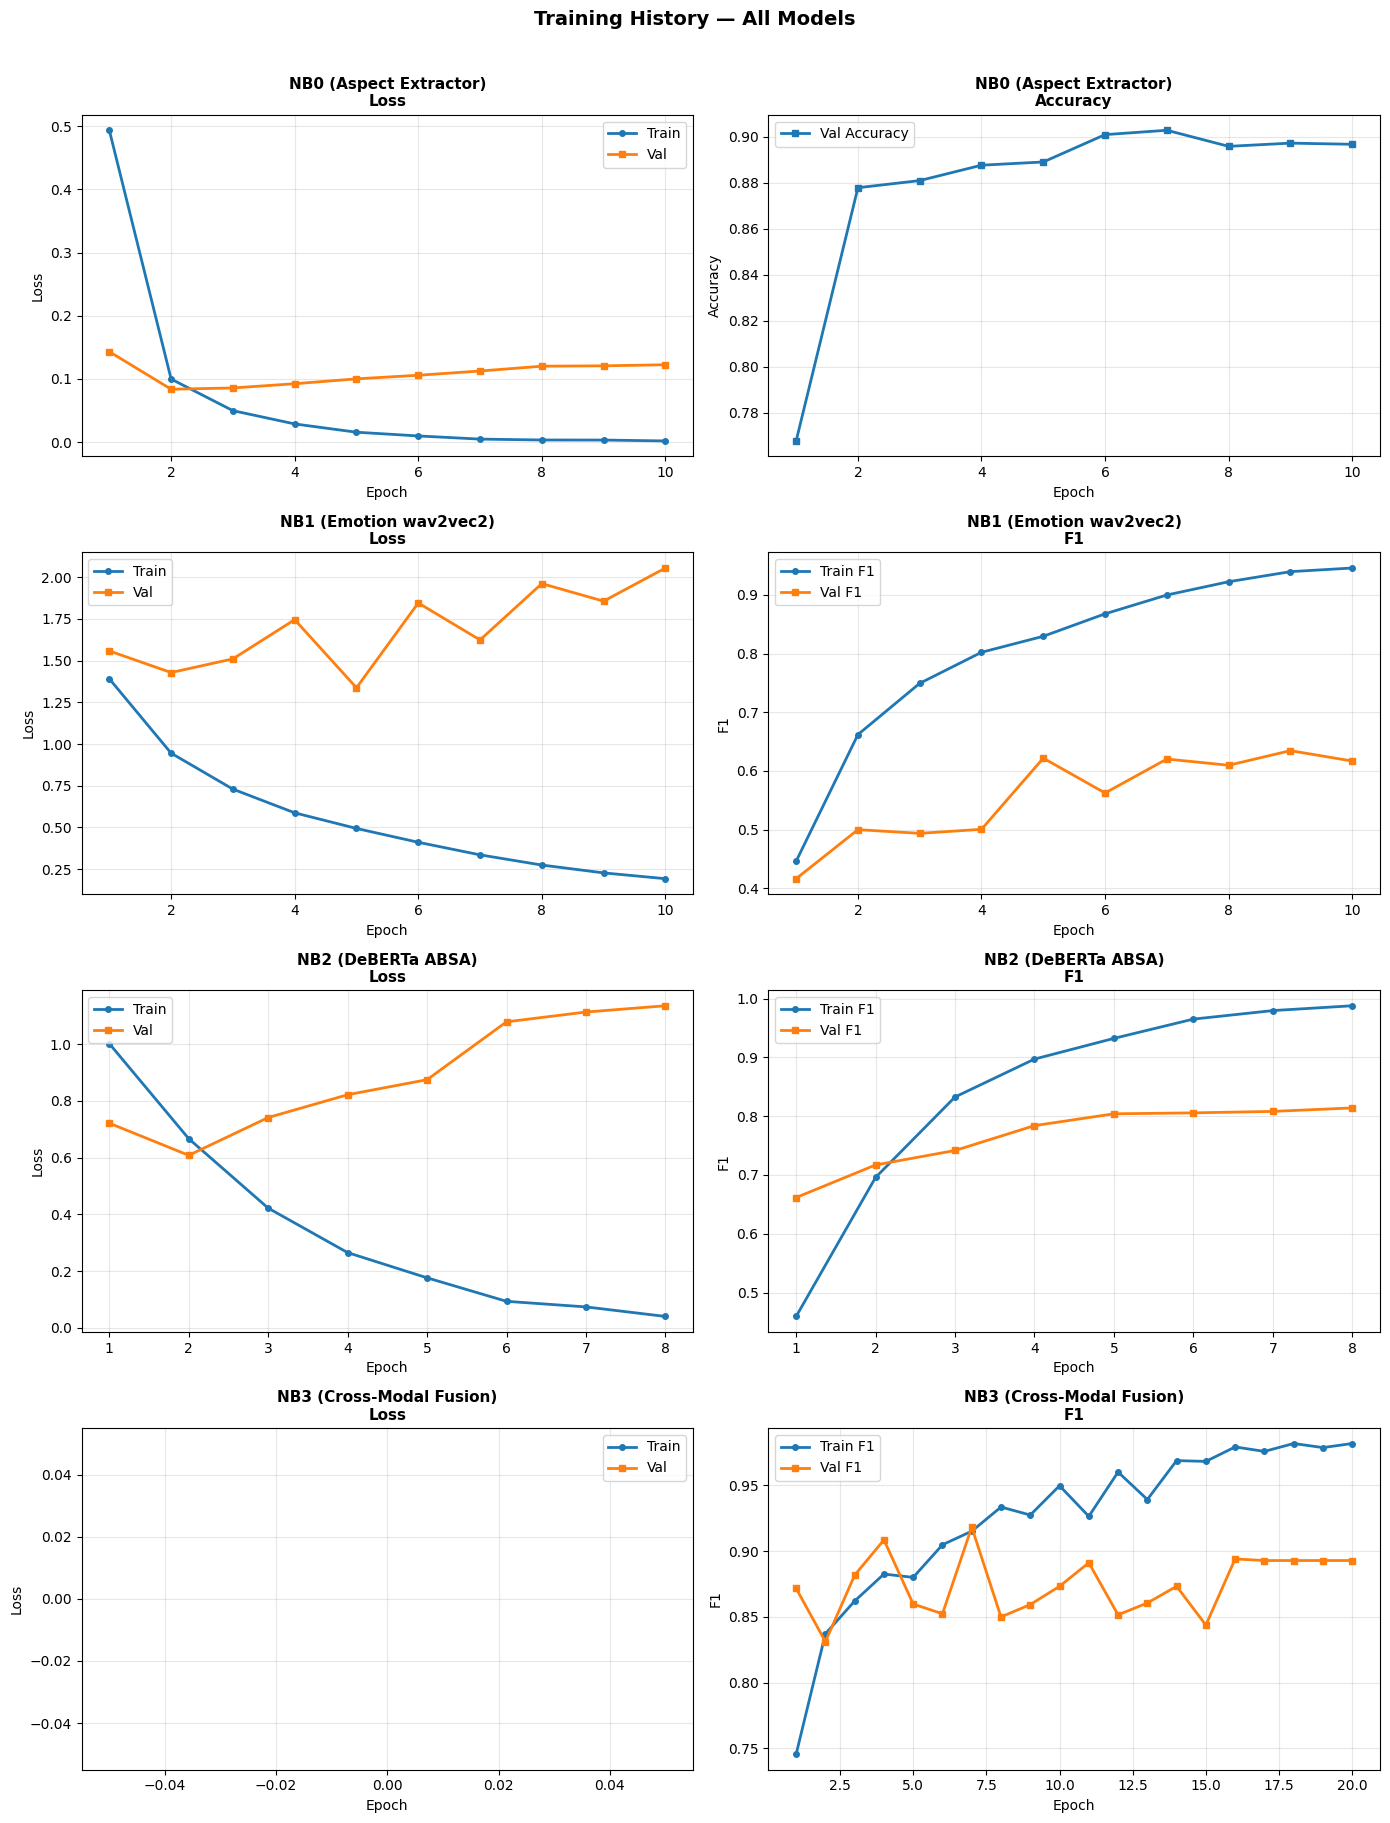

✅ Saved: /content/training_history.png


In [ ]:
# CELL 5 — Training history curves (one plot per model)
models_with_history = [
    (name, res) for name, res in results.items()
    if 'history' in res and res['history']
]

if not models_with_history:
    print('No training history found in results files.')
else:
    n = len(models_with_history)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4.5 * n))
    if n == 1: axes = [axes]  # ensure 2D indexing

    for row_idx, (name, res) in enumerate(models_with_history):
        history = res['history']
        epochs  = [h['epoch'] for h in history]

        ax_loss = axes[row_idx][0]
        ax_f1   = axes[row_idx][1]

        # Loss
        tr_loss = [h.get('tr_loss', h.get('train_loss', None)) for h in history]
        vl_loss = [h.get('vl_loss', h.get('val_loss',   None)) for h in history]
        if any(v is not None for v in tr_loss):
            ax_loss.plot(epochs, tr_loss, label='Train', linewidth=2, marker='o', ms=4)
        if any(v is not None for v in vl_loss):
            ax_loss.plot(epochs, vl_loss, label='Val',   linewidth=2, marker='s', ms=4)
        ax_loss.set_title(f'{name}\nLoss', fontsize=11, fontweight='bold')
        ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
        ax_loss.legend(); ax_loss.grid(True, alpha=0.3)

        # F1 / Accuracy
        # Try F1 first, fall back to accuracy
        tr_metric = [h.get('tr_f1', h.get('tr_acc', None)) for h in history]
        vl_metric = [h.get('vl_f1', h.get('vl_acc', None)) for h in history]
        metric_name = 'F1' if 'tr_f1' in history[0] else 'Accuracy'
        if any(v is not None for v in tr_metric):
            ax_f1.plot(epochs, tr_metric, label=f'Train {metric_name}', linewidth=2, marker='o', ms=4)
        if any(v is not None for v in vl_metric):
            ax_f1.plot(epochs, vl_metric, label=f'Val {metric_name}',   linewidth=2, marker='s', ms=4)
        ax_f1.set_title(f'{name}\n{metric_name}', fontsize=11, fontweight='bold')
        ax_f1.set_xlabel('Epoch'); ax_f1.set_ylabel(metric_name)
        ax_f1.legend(); ax_f1.grid(True, alpha=0.3)

    plt.suptitle('Training History — All Models', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig('/content/training_history.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('✅ Saved: /content/training_history.png')

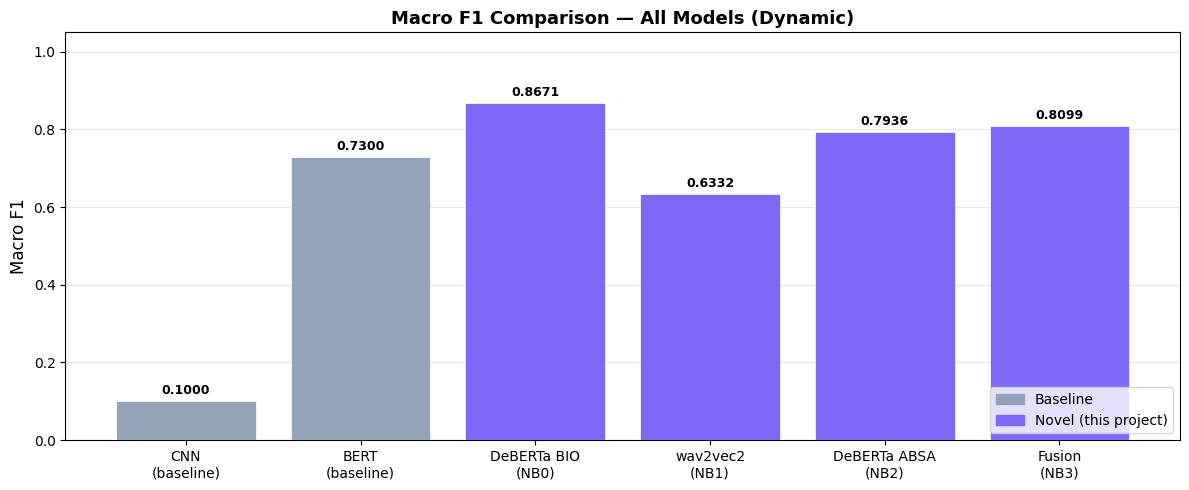

✅ Saved: /content/macro_f1_comparison.png


In [ ]:
# CELL 6 — Bar chart comparison (Macro F1 across all models)
import matplotlib.patches as mpatches

compare_data = []

# Baselines
compare_data.append({'Model': 'CNN\n(baseline)', 'F1': 0.10, 'Type': 'Baseline'})
compare_data.append({'Model': 'BERT\n(baseline)', 'F1': 0.73, 'Type': 'Baseline'})

# Dynamic
if 'NB0 (Aspect Extractor)' in results:
    compare_data.append({
        'Model': 'DeBERTa BIO\n(NB0)',
        'F1': results['NB0 (Aspect Extractor)'].get('test_f1', 0),
        'Type': 'Novel'
    })
if 'NB1 (Emotion wav2vec2)' in results:
    compare_data.append({
        'Model': 'wav2vec2\n(NB1)',
        'F1': results['NB1 (Emotion wav2vec2)'].get('test_macro_f1', 0),
        'Type': 'Novel'
    })
if 'NB2 (DeBERTa ABSA)' in results:
    compare_data.append({
        'Model': 'DeBERTa ABSA\n(NB2)',
        'F1': results['NB2 (DeBERTa ABSA)'].get('test_macro_f1', 0),
        'Type': 'Novel'
    })
if 'NB3 (Cross-Modal Fusion)' in results:
    compare_data.append({
        'Model': 'Fusion\n(NB3)',
        'F1': results['NB3 (Cross-Modal Fusion)'].get('test_macro_f1', 0),
        'Type': 'Novel'
    })

df_cmp = pd.DataFrame(compare_data)
colors = ['#94a3b8' if t == 'Baseline' else '#7c6af7' for t in df_cmp['Type']]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(df_cmp['Model'], df_cmp['F1'], color=colors,
               edgecolor='white', linewidth=0.5, zorder=3)

# Value labels on bars
for bar, val in zip(bars, df_cmp['F1']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_ylim(0, 1.05)
ax.set_ylabel('Macro F1', fontsize=12)
ax.set_title('Macro F1 Comparison — All Models (Dynamic)', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_axisbelow(True)

legend = [
    mpatches.Patch(color='#94a3b8', label='Baseline'),
    mpatches.Patch(color='#7c6af7', label='Novel (this project)'),
]
ax.legend(handles=legend, loc='lower right')
plt.tight_layout()
plt.savefig('/content/macro_f1_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Saved: /content/macro_f1_comparison.png')

In [ ]:
# CELL 7 — Live inference test on sample sentences using saved NB0 + NB2 models
# This re-evaluates the CURRENT models from Drive — fully dynamic
import shutil, torch

ASP_DIR  = os.path.join(BASE, 'aspect_extractor/best_model')
TEXT_DIR = os.path.join(BASE, 'deberta_absa/best_model')
LOCAL_ASP  = '/content/asp_eval'
LOCAL_TEXT = '/content/text_eval'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ID2LABEL_BIO       = {0:'O', 1:'B-ASP', 2:'I-ASP'}
ID2LABEL_SENTIMENT = {0:'negative', 1:'neutral', 2:'positive'}

if not os.path.exists(LOCAL_ASP):
    print('Copying aspect extractor...')
    shutil.copytree(ASP_DIR, LOCAL_ASP)
if not os.path.exists(LOCAL_TEXT):
    print('Copying DeBERTa...')
    shutil.copytree(TEXT_DIR, LOCAL_TEXT)

from transformers import AutoTokenizer, AutoModelForTokenClassification, AutoModelForSequenceClassification

asp_tok = AutoTokenizer.from_pretrained(LOCAL_ASP)
asp_mdl = AutoModelForTokenClassification.from_pretrained(LOCAL_ASP).to(DEVICE).eval()
txt_tok = AutoTokenizer.from_pretrained(LOCAL_TEXT)
txt_mdl = AutoModelForSequenceClassification.from_pretrained(LOCAL_TEXT).to(DEVICE).eval()
print(f'✅ Models loaded on {DEVICE}')

Copying aspect extractor...
Copying DeBERTa...
✅ Models loaded on cuda


In [ ]:
# CELL 8 — Aspect extraction helper
def extract_aspects(text, max_len=128):
    enc = asp_tok(text, max_length=max_len, truncation=True,
                   return_offsets_mapping=True, return_tensors='pt')
    offsets = enc['offset_mapping'][0].tolist()
    inp = {k: v.to(DEVICE) for k, v in enc.items() if k != 'offset_mapping'}
    with torch.no_grad():
        preds = asp_mdl(**inp).logits.argmax(-1)[0].cpu().tolist()
    aspects = []
    cur_s = cur_e = None
    for lid, (cs, ce) in zip(preds, offsets):
        lbl = ID2LABEL_BIO[lid]
        if cs == 0 and ce == 0:
            if cur_s is not None:
                span = text[cur_s:cur_e].strip()
                if span: aspects.append(span)
                cur_s = cur_e = None
            continue
        if lbl == 'B-ASP':
            if cur_s is not None:
                span = text[cur_s:cur_e].strip()
                if span: aspects.append(span)
            cur_s, cur_e = cs, ce
        elif lbl == 'I-ASP':
            if cur_s is not None: cur_e = ce
            else: cur_s, cur_e = cs, ce
        else:
            if cur_s is not None:
                span = text[cur_s:cur_e].strip()
                if span: aspects.append(span)
                cur_s = cur_e = None
    if cur_s is not None:
        span = text[cur_s:cur_e].strip()
        if span: aspects.append(span)
    seen, unique = set(), []
    for a in aspects:
        if a.lower() not in seen: seen.add(a.lower()); unique.append(a)
    return unique

def classify_aspects(transcript, aspects):
    results = []
    for asp in aspects:
        enc = txt_tok(transcript, asp, return_tensors='pt',
                      max_length=128, truncation=True, padding='max_length')
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            probs = torch.softmax(txt_mdl(**enc).logits, dim=-1).squeeze(0).cpu().numpy()
        results.append({
            'aspect': asp,
            'sentiment': ID2LABEL_SENTIMENT[int(probs.argmax())],
            'confidence': round(float(probs.max()), 3),
            'neg': round(float(probs[0]),3),
            'neu': round(float(probs[1]),3),
            'pos': round(float(probs[2]),3),
        })
    return sorted(results, key=lambda x: x['confidence'], reverse=True)

print('✅ Inference helpers ready')

✅ Inference helpers ready


In [ ]:
# CELL 9 — Live inference on test sentences
test_sentences = [
    'The pizza was amazing but the service was really slow.',
    'Great food and friendly staff but the prices are too high and parking is terrible.',
    'The pasta was overcooked and the waiter was rude but the dessert was fantastic.',
    'Excellent ambiance and the wine selection is superb though the wait time was long.',
    'The grilled chicken and the chocolate cake were both outstanding.',
    'Not only was the food outstanding but the little perks were great.',
    'The bread is top notch as well.',
]

print('📊 LIVE INFERENCE TEST — Current Models from Drive')
print('='*70)

all_rows = []
for sent in test_sentences:
    aspects = extract_aspects(sent)
    if aspects:
        preds = classify_aspects(sent, aspects)
        for p in preds:
            all_rows.append({
                'Sentence': sent[:50] + '...' if len(sent) > 50 else sent,
                'Aspect':   p['aspect'],
                'Sentiment':p['sentiment'],
                'Conf':     p['confidence'],
                'neg':      p['neg'],
                'neu':      p['neu'],
                'pos':      p['pos'],
            })
    else:
        all_rows.append({
            'Sentence': sent[:50]+'...' if len(sent)>50 else sent,
            'Aspect': '(none found)', 'Sentiment': '-',
            'Conf': 0, 'neg':0,'neu':0,'pos':0
        })

df_inf = pd.DataFrame(all_rows)
print(df_inf.to_string(index=False))

📊 LIVE INFERENCE TEST — Current Models from Drive
                                             Sentence          Aspect Sentiment  Conf   neg   neu   pos
The pizza was amazing but the service was really s...           pizza  positive 1.000 0.000 0.000 1.000
The pizza was amazing but the service was really s...         service  negative 0.999 0.999 0.000 0.000
Great food and friendly staff but the prices are t...            food  positive 1.000 0.000 0.000 1.000
Great food and friendly staff but the prices are t...           staff  positive 1.000 0.000 0.000 1.000
Great food and friendly staff but the prices are t...         parking  negative 0.999 0.999 0.000 0.000
Great food and friendly staff but the prices are t...          prices  negative 0.997 0.997 0.001 0.002
The pasta was overcooked and the waiter was rude b...         dessert  positive 1.000 0.000 0.000 1.000
The pasta was overcooked and the waiter was rude b...           pasta  negative 0.999 0.999 0.000 0.000
The pasta was 

In [ ]:
# CELL 10 — Evaluate NB2 on held-out test split (quantitative accuracy)
# Loads SemEval CSV, does 70/15/15 split with SAME seed as NB2
# Evaluates current deberta_absa model — dynamically reflects any retraining

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix

TRAIN_CSV = os.path.join(BASE, 'Dataset/SemEval 2014 Task 4/Restaurants_Train_v2.csv')
SEED = 42
LABEL2ID = {'negative':0, 'neutral':1, 'positive':2}

raw = pd.read_csv(TRAIN_CSV)
raw.columns = raw.columns.str.strip()
df = raw[['Sentence','Aspect Term','polarity']].copy()
df.columns = ['text','aspect','polarity']
df = df[df['polarity'].isin(LABEL2ID)].dropna().reset_index(drop=True)
df['label'] = df['polarity'].map(LABEL2ID)

# Same 70/15/15 split as NB2
_, tmp = train_test_split(df, test_size=0.30, stratify=df['label'], random_state=SEED)
_, test_df = train_test_split(tmp, test_size=0.50, stratify=tmp['label'], random_state=SEED)
test_df = test_df.reset_index(drop=True)
print(f'Test samples: {len(test_df)}')
print(test_df['polarity'].value_counts().to_string())

Test samples: 541
polarity
positive    325
negative    121
neutral      95


In [ ]:
# CELL 11 — Run NB2 evaluation on test split
print('Running NB2 evaluation on test split (current model from Drive)...')

preds_nb2, golds_nb2 = [], []
batch_size = 32
ID2LABEL_SENT = {0:'negative', 1:'neutral', 2:'positive'}

for i in range(0, len(test_df), batch_size):
    batch = test_df.iloc[i:i+batch_size]
    for _, row in batch.iterrows():
        enc = txt_tok(row['text'], row['aspect'],
                      return_tensors='pt', max_length=128,
                      truncation=True, padding='max_length')
        enc = {k: v.to(DEVICE) for k, v in enc.items()}
        with torch.no_grad():
            probs = torch.softmax(txt_mdl(**enc).logits, dim=-1).squeeze(0).cpu().numpy()
        preds_nb2.append(int(probs.argmax()))
        golds_nb2.append(int(row['label']))
    if (i // batch_size + 1) % 5 == 0:
        print(f'  {i+len(batch)}/{len(test_df)} done...')

acc_nb2 = accuracy_score(golds_nb2, preds_nb2)
f1_nb2  = f1_score(golds_nb2, preds_nb2, average='macro', zero_division=0)
pr_nb2  = precision_score(golds_nb2, preds_nb2, average='macro', zero_division=0)
rc_nb2  = recall_score(golds_nb2, preds_nb2, average='macro', zero_division=0)

print('\n📊 NB2 LIVE EVALUATION (current model from Drive)')
print('='*50)
print(pd.DataFrame([
    {'Metric':'Accuracy',  'Score': f'{acc_nb2*100:.2f}%'},
    {'Metric':'Macro F1',  'Score': f'{f1_nb2:.4f}'},
    {'Metric':'Precision', 'Score': f'{pr_nb2:.4f}'},
    {'Metric':'Recall',    'Score': f'{rc_nb2:.4f}'},
]).to_string(index=False))
print('='*50)
print('\n📊 PER-CLASS REPORT')
print(classification_report(golds_nb2, preds_nb2,
    target_names=[ID2LABEL_SENT[i] for i in range(3)], zero_division=0))

Running NB2 evaluation on test split (current model from Drive)...
  160/541 done...
  320/541 done...
  480/541 done...

📊 NB2 LIVE EVALUATION (current model from Drive)
   Metric  Score
 Accuracy 84.66%
 Macro F1 0.7936
Precision 0.7935
   Recall 0.7939

📊 PER-CLASS REPORT
              precision    recall  f1-score   support

    negative       0.78      0.80      0.79       121
     neutral       0.68      0.66      0.67        95
    positive       0.92      0.92      0.92       325

    accuracy                           0.85       541
   macro avg       0.79      0.79      0.79       541
weighted avg       0.85      0.85      0.85       541



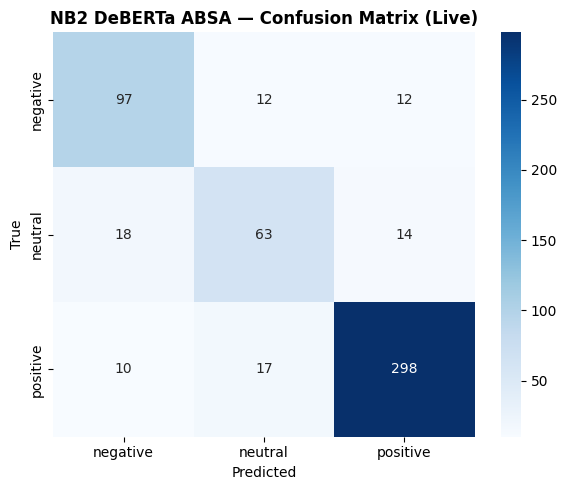

✅ Saved: /content/nb2_confusion_matrix.png


In [ ]:
# CELL 12 — Confusion matrix for NB2
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(golds_nb2, preds_nb2)
labels = [ID2LABEL_SENT[i] for i in range(3)]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
    xticklabels=labels, yticklabels=labels)
ax.set_title('NB2 DeBERTa ABSA — Confusion Matrix (Live)', fontweight='bold')
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
plt.tight_layout()
plt.savefig('/content/nb2_confusion_matrix.png', dpi=120)
plt.show()
print('✅ Saved: /content/nb2_confusion_matrix.png')

In [ ]:
import sys
!{sys.executable} -m pip install seqeval

# CELL 13 — Evaluate NB0 on held-out test split (aspect extraction F1)
from seqeval.metrics import f1_score as seq_f1, precision_score as seq_pr, recall_score as seq_rc

TRAIN_CSV_NB0 = TRAIN_CSV
raw0 = pd.read_csv(TRAIN_CSV_NB0)
raw0.columns = raw0.columns.str.strip()

# Group by sentence
sentence_aspects = {}
for _, row in raw0.iterrows():
    sid  = str(row['id'])
    text = str(row['Sentence']).strip()
    term = str(row['Aspect Term']).strip()
    try: cf, ct = int(row['from']), int(row['to'])
    except: continue
    key = (sid, text)
    sentence_aspects.setdefault(key, []).append((term, cf, ct))

all_samples = list(sentence_aspects.items())
_, tmp0 = train_test_split(all_samples, test_size=0.30, random_state=SEED)
_, te0  = train_test_split(tmp0, test_size=0.50, random_state=SEED)
print(f'NB0 test samples: {len(te0)}')

# Evaluate on test sentences
ID2LABEL_BIO = {0:'O', 1:'B-ASP', 2:'I-ASP'}
all_preds_bio, all_golds_bio = [], []

for (sid, text), true_aspects in te0:
    enc = asp_tok(text, max_length=128, truncation=True,
                   return_offsets_mapping=True, return_tensors='pt')
    offsets = enc['offset_mapping'][0].tolist()
    inp = {k: v.to(DEVICE) for k, v in enc.items() if k != 'offset_mapping'}
    with torch.no_grad():
        pred_ids = asp_mdl(**inp).logits.argmax(-1)[0].cpu().tolist()

    # Build gold BIO sequence
    asp_ranges = [(cf, ct) for (_, cf, ct) in true_aspects]
    gold_ids = []
    for (cs, ce) in offsets:
        if cs == 0 and ce == 0: gold_ids.append(-100); continue
        assigned = 'O'
        for (as_, ae) in asp_ranges:
            if cs < ae and ce > as_:
                assigned = 'B-ASP' if cs <= as_ else 'I-ASP'
                break
        gold_ids.append({'O':0,'B-ASP':1,'I-ASP':2}[assigned])

    # Convert to seqeval format (skip -100)
    p_seq, g_seq = [], []
    for p, g in zip(pred_ids, gold_ids):
        if g == -100: continue
        p_seq.append(ID2LABEL_BIO[p])
        g_seq.append(ID2LABEL_BIO[g])
    all_preds_bio.append(p_seq)
    all_golds_bio.append(g_seq)

f1_nb0 = seq_f1(all_golds_bio, all_preds_bio)
pr_nb0 = seq_pr(all_golds_bio, all_preds_bio)
rc_nb0 = seq_rc(all_golds_bio, all_preds_bio)

print('\n📊 NB0 LIVE EVALUATION (current model from Drive)')
print('='*50)
print(pd.DataFrame([
    {'Metric':'Span F1',        'Score': f'{f1_nb0:.4f}'},
    {'Metric':'Span Precision', 'Score': f'{pr_nb0:.4f}'},
    {'Metric':'Span Recall',    'Score': f'{rc_nb0:.4f}'},
]).to_string(index=False))
print('='*50)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=b124605fac8973ba0e02f21f3c77e3141381db3fd50ad8c865089640fdc5cda2
  Stored in directory: /root/.cache/pip/wheels/5f/b8/73/0b2c1a76b701a677653dd79ece07cfabd7457989dbfbdcd8d7
Successfully built seqeval
NB0 test samples: 304

📊 NB0 LIVE EVALUATION (current model from Drive)
        Metric  Score
       Span F1 0.8671
Span Precision 0.8548
   Span Recall 0.8797


In [ ]:
# CELL 14 — Final summary: saved JSON results vs live evaluation
print('='*70)
print('📊 FINAL SUMMARY — Saved Results vs Live Evaluation')
print('='*70)

summary_rows = []

# NB0
saved_nb0 = results.get('NB0 (Aspect Extractor)', {})
summary_rows.append({
    'Model':         'NB0 Aspect Extractor',
    'Metric':        'Span F1',
    'Saved (JSON)':  saved_nb0.get('test_f1', 'N/A'),
    'Live Eval':     round(f1_nb0, 4),
    'Match':         '✅' if abs(saved_nb0.get('test_f1',0) - f1_nb0) < 0.01 else '⚠️ Different'
})

# NB2
saved_nb2 = results.get('NB2 (DeBERTa ABSA)', {})
summary_rows.append({
    'Model':         'NB2 DeBERTa ABSA',
    'Metric':        'Macro F1',
    'Saved (JSON)':  saved_nb2.get('test_macro_f1', 'N/A'),
    'Live Eval':     round(f1_nb2, 4),
    'Match':         '✅' if abs(saved_nb2.get('test_macro_f1',0) - f1_nb2) < 0.01 else '⚠️ Different'
})

# NB1 and NB3 (from saved JSON only — need audio datasets to re-evaluate live)
saved_nb1 = results.get('NB1 (Emotion wav2vec2)', {})
if saved_nb1:
    summary_rows.append({
        'Model':        'NB1 wav2vec2 Emotion',
        'Metric':       'Macro F1',
        'Saved (JSON)': saved_nb1.get('test_macro_f1','N/A'),
        'Live Eval':    'N/A (needs audio dataset)',
        'Match':        'N/A'
    })

saved_nb3 = results.get('NB3 (Cross-Modal Fusion)', {})
if saved_nb3:
    summary_rows.append({
        'Model':        'NB3 Cross-Modal Fusion',
        'Metric':       'Macro F1',
        'Saved (JSON)': saved_nb3.get('test_macro_f1','N/A'),
        'Live Eval':    'N/A (needs audio dataset)',
        'Match':        'N/A'
    })

print(pd.DataFrame(summary_rows).to_string(index=False))
print('\nNote: "Match" compares saved vs live — if ⚠️ Different, the model was retrained.')
print('      Live Eval always reflects the CURRENT model weights from Drive.')

📊 FINAL SUMMARY — Saved Results vs Live Evaluation
                 Model   Metric  Saved (JSON)                 Live Eval Match
  NB0 Aspect Extractor  Span F1        0.8671                    0.8671     ✅
      NB2 DeBERTa ABSA Macro F1        0.7936                    0.7936     ✅
  NB1 wav2vec2 Emotion Macro F1        0.6332 N/A (needs audio dataset)   N/A
NB3 Cross-Modal Fusion Macro F1        0.8099 N/A (needs audio dataset)   N/A

Note: "Match" compares saved vs live — if ⚠️ Different, the model was retrained.
      Live Eval always reflects the CURRENT model weights from Drive.
